In [26]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# matplotlib配置
# 浏览器不显示图片
%matplotlib inline

# 图片中文显示
plt.rcParams["font.sans-serif"] = "SimHei"

# 图片中显示负号
plt.rcParams["axes.unicode_minus"] = False

# 支持svg矢量图
%config InlineBackend.figure_format = "svg"

In [2]:
data = pd.read_excel("./data/user1111.xlsx")
data

,username,last_login_time,login_count,addtime
0,mr000001,2017-01-01 01:57:52,0,2017-01-01 01:57:52
1,mr000002,2017-01-01 07:33:54,0,2017-01-01 07:33:54
2,mr000003,2017-01-01 07:50:34,0,2017-01-01 07:50:34
3,mr000004,2017-01-01 12:28:19,0,2017-01-01 12:28:19
4,mr000005,2017-01-01 12:44:30,0,2017-01-01 12:44:30
...,...,...,...,...
192303,mr192304,2019-12-31 23:16:47,2,2019-12-31 23:01:09
192304,mr192305,2019-12-31 23:16:40,1,2019-12-31 23:16:40
192305,mr192306,2019-12-31 23:16:58,1,2019-12-31 23:16:58
192306,mr192307,2020-01-05 16:10:24,6,2019-12-31 23:17:33


In [3]:
data = data[['addtime','username']]
data.rename(columns = {'addtime':'注册日期','username':'用户数量'},inplace=True)
data['注册日期'] = pd.to_datetime(data['注册日期'])
data = data.set_index('注册日期')

C:\Users\18281\AppData\Local\Temp\ipykernel_21464\3825908367.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.rename(columns = {'addtime':'注册日期','username':'用户数量'},inplace=True)
C:\Users\18281\AppData\Local\Temp\ipykernel_21464\3825908367.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['注册日期'] = pd.to_datetime(data['注册日期'])


In [12]:
data1 = data.resample("M").size().to_period("M")
data1

注册日期
2017-01      556
2017-02      659
2017-03      814
2017-04      814
2017-05      848
2017-06     1068
2017-07     1544
2017-08     1378
2017-09     1537
2017-10     2305
2017-11     3675
2017-12     3265
2018-01     3983
2018-02     3676
2018-03     6877
2018-04    11394
2018-05     6284
2018-06     5574
2018-07    10387
2018-08     7940
2018-09     7672
2018-10     7484
2018-11     7895
2018-12     6414
2019-01     5863
2019-02     5160
2019-03     7865
2019-04     6391
2019-05     6355
2019-06     7344
2019-07     9216
2019-08     7612
2019-09     7609
2019-10     8438
2019-11     8929
2019-12     7483
Freq: M, dtype: int64

In [21]:
index = ['1月','2月','3月','4月','5月','6月','7月','8月','9月','10月','11月','12月']

In [23]:
data_17 = data1['2017-01':'2017-12']
data_17.index = index

In [24]:
data_18 = data1['2018-01':'2018-12']
data_18.index = index

In [25]:
data_19 = data1['2019-01':'2019-12']
data_19.index = index

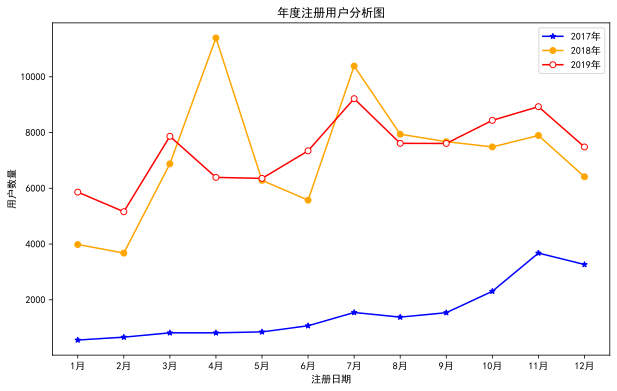

In [37]:
plt.figure(figsize=(10,6),dpi=150)
plt.title("年度注册用户分析图")

plt.plot(data_17.index,data_17,color='b',marker='*',label='2017年')
plt.plot(data_18.index,data_18,color='orange',marker='o',label='2018年')
plt.plot(data_19.index,data_19,color='red',marker='o',mfc='w',label='2019年')

plt.xlabel("注册日期")
plt.ylabel("用户数量")
plt.legend()

plt.show()

In [38]:
data2 = data.resample("D").size().to_period("D")
data2

注册日期
2017-01-01     24
2017-01-02     25
2017-01-03     25
2017-01-04     26
2017-01-05     24
             ... 
2019-12-27    230
2019-12-28    230
2019-12-29    236
2019-12-30    260
2019-12-31    185
Freq: D, Length: 1095, dtype: int64

In [39]:
data_apr = data2['2018-04-01':'2018-04-30']
data_apr

注册日期
2018-04-01     128
2018-04-02     336
2018-04-03     252
2018-04-04     193
2018-04-05     236
2018-04-06     243
2018-04-07     228
2018-04-08     244
2018-04-09     282
2018-04-10     268
2018-04-11     225
2018-04-12    1015
2018-04-13    1197
2018-04-14     737
2018-04-15     505
2018-04-16     457
2018-04-17     383
2018-04-18     323
2018-04-19     305
2018-04-20     250
2018-04-21     299
2018-04-22     467
2018-04-23     592
2018-04-24     468
2018-04-25     385
2018-04-26     355
2018-04-27     268
2018-04-28     228
2018-04-29     278
2018-04-30     247
Freq: D, dtype: int64

In [40]:
x_index = pd.date_range(start='20180401',periods=30)
x_index

DatetimeIndex(['2018-04-01', '2018-04-02', '2018-04-03', '2018-04-04',
               '2018-04-05', '2018-04-06', '2018-04-07', '2018-04-08',
               '2018-04-09', '2018-04-10', '2018-04-11', '2018-04-12',
               '2018-04-13', '2018-04-14', '2018-04-15', '2018-04-16',
               '2018-04-17', '2018-04-18', '2018-04-19', '2018-04-20',
               '2018-04-21', '2018-04-22', '2018-04-23', '2018-04-24',
               '2018-04-25', '2018-04-26', '2018-04-27', '2018-04-28',
               '2018-04-29', '2018-04-30'],
              dtype='datetime64[ns]', freq='D')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


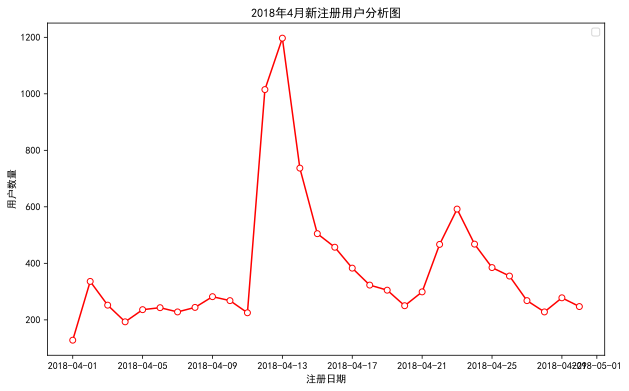

In [41]:
plt.figure(figsize=(10,6),dpi=150)
plt.title("2018年4月新注册用户分析图")

plt.plot(x_index,data_apr,color='red',marker='o',mfc='w')

plt.xlabel("注册日期")
plt.ylabel("用户数量")
plt.legend()

plt.show()